# Nuclear cross sections with Pythia8 Cascade and Angantyr

This notebook demonstrates how to obtain nuclear interaction cross sections
from the two Pythia8 nuclear modes in chromo:

- **Pythia8Cascade** -- uses a parametric formula (PythiaCascade `nCollAvg` table)
- **Pythia8Angantyr** -- provides fast parametric estimates by default, and
  precise Glauber Monte-Carlo cross sections via `glauber_cross_section()`

We compare these with other models that support nuclear targets.

In [1]:
import warnings

import numpy as np
from matplotlib import pyplot as plt

from chromo.constants import GeV
from chromo.kinematics import CenterOfMass, FixedTarget
from chromo.models.pythia8 import Pythia8Angantyr, Pythia8Cascade

## 1. Basic cross-section queries

Both Cascade and Angantyr return cross sections through the standard
`cross_section()` interface.  Cascade uses a fixed-target frame;
Angantyr uses center-of-mass.

In [2]:
# Pythia8Cascade: fixed-target h+A mode
cascade = Pythia8Cascade(FixedTarget(100 * GeV, "p", "N14"), seed=1, banner=False)
cs_cascade = cascade.cross_section()
print("Pythia8Cascade  p + N14 @ 100 GeV plab")
print(f"  inelastic = {cs_cascade.inelastic:.1f} mb")
print(f"  prod      = {cs_cascade.prod:.1f} mb")

Pythia8Cascade  p + N14 @ 100 GeV plab
  inelastic = 254.5 mb
  prod      = 254.5 mb


In [3]:
# Pythia8Angantyr: cross_section() returns fast parametric estimates
angantyr = Pythia8Angantyr(CenterOfMass(100 * GeV, "p", "N14"), seed=1, banner=False)

# The default cross_section() uses the PythiaCascade parametric formula
# (no event generation needed, deterministic).
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suppress the "parametric" hint
    cs_param = angantyr.cross_section()

print("Pythia8Angantyr  p + N14 @ 100 GeV CMS")
print(f"  parametric inelastic = {cs_param.inelastic:.1f} mb")
print(f"  parametric prod      = {cs_param.prod:.1f} mb")

Pythia8Angantyr  p + N14 @ 100 GeV CMS
  parametric inelastic = 291.4 mb
  parametric prod      = 291.4 mb


## 2. Angantyr Glauber cross sections

For precise nuclear cross sections, call `glauber_cross_section(n_trials)`.
This runs Angantyr in GlauberOnly mode and returns total, inelastic, and
elastic cross sections from the Glauber Monte Carlo.

In [4]:
# glauber_cross_section() runs GlauberOnly MC trials -- more accurate but slower
cs_glauber = angantyr.glauber_cross_section(n_trials=10000)

print("Pythia8Angantyr  p + N14 @ 100 GeV CMS  (Glauber MC, 10k trials)")
print(f"  total     = {cs_glauber.total:.1f} mb")
print(f"  inelastic = {cs_glauber.inelastic:.1f} mb")
print(f"  elastic   = {cs_glauber.elastic:.1f} mb")
print(f"  prod      = {cs_glauber.prod:.1f} mb")
print()
print(f"Parametric vs Glauber inelastic: "
      f"{cs_param.inelastic:.1f} vs {cs_glauber.inelastic:.1f} mb "
      f"({abs(cs_param.inelastic - cs_glauber.inelastic) / cs_glauber.inelastic * 100:.1f}% difference)")

# Free early instances before the heavier loops
del cascade, angantyr

Pythia8Angantyr  p + N14 @ 100 GeV CMS  (Glauber MC, 10k trials)
  total     = 405.2 mb
  inelastic = 291.4 mb
  elastic   = 113.8 mb
  prod      = 291.4 mb

Parametric vs Glauber inelastic: 291.4 vs 291.4 mb (0.0% difference)


## 3. Energy dependence: parametric vs Glauber

Scan the inelastic cross section over a range of CMS energies for
p + N14, comparing the fast parametric estimate with the Glauber MC.

In [5]:
energies = np.geomspace(20, 1e5, 15) * GeV

sigma_param = []
sigma_glauber = []

ang = Pythia8Angantyr(CenterOfMass(energies[-1], "p", "N14"), seed=1, banner=False)

for ecm in energies:
    kin = CenterOfMass(ecm, "p", "N14")
    # Parametric (fast, no events)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sigma_param.append(ang.cross_section(kin).inelastic)
    # Glauber MC (precise, uses kin= interface)
    sigma_glauber.append(ang.glauber_cross_section(kin, n_trials=5000).inelastic)

sigma_param = np.array(sigma_param)
sigma_glauber = np.array(sigma_glauber)
del ang

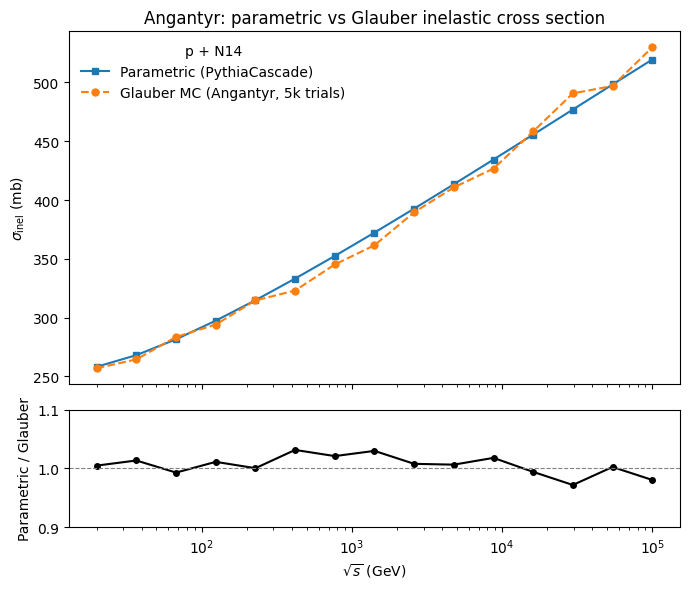

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(energies / GeV, sigma_param, "s-", label="Parametric (PythiaCascade)", ms=5)
ax1.plot(energies / GeV, sigma_glauber, "o--", label="Glauber MC (Angantyr, 5k trials)", ms=5)
ax1.set_xscale("log")
ax1.set_ylabel(r"$\sigma_\mathrm{inel}$ (mb)")
ax1.legend(frameon=False, title="p + N14")
ax1.set_title("Angantyr: parametric vs Glauber inelastic cross section")

ratio = sigma_param / sigma_glauber
ax2.plot(energies / GeV, ratio, "ko-", ms=4)
ax2.axhline(1, color="gray", ls="--", lw=0.8)
ax2.set_xlabel(r"$\sqrt{s}$ (GeV)")
ax2.set_ylabel("Parametric / Glauber")
ax2.set_ylim(0.9, 1.1)

plt.tight_layout()

## 4. Target dependence

Compare the parametric inelastic cross section for different target nuclei
at a fixed CMS energy.  Cascade and Angantyr agree since both use the same
underlying PythiaCascade `nCollAvg` formula for the parametric estimate.

In [7]:
targets_cascade = ["He4", "N14", "O16", "Ar40", "Fe56", "Pb208"]
targets_angantyr = ["He4", "C12", "N14", "O16", "Ar40", "Cu63", "Xe129", "Pb208"]
ecm = 100 * GeV

# Cascade: reuse one instance, switch targets via cross_section(kin)
cas = Pythia8Cascade(CenterOfMass(ecm, "p", targets_cascade[0]), seed=1, banner=False)
sigma_cascade = {}
for t in targets_cascade:
    kin = CenterOfMass(ecm, "p", t)
    sigma_cascade[t] = cas.cross_section(kin).inelastic
del cas

# Angantyr: parametric + Glauber, both using kin= interface
ang = Pythia8Angantyr(CenterOfMass(ecm, "p", targets_angantyr[0]), seed=1, banner=False)
sigma_angantyr_param = {}
sigma_angantyr_glauber = {}
for t in targets_angantyr:
    kin = CenterOfMass(ecm, "p", t)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sigma_angantyr_param[t] = ang.cross_section(kin).inelastic
    sigma_angantyr_glauber[t] = ang.glauber_cross_section(kin, n_trials=5000).inelastic
del ang

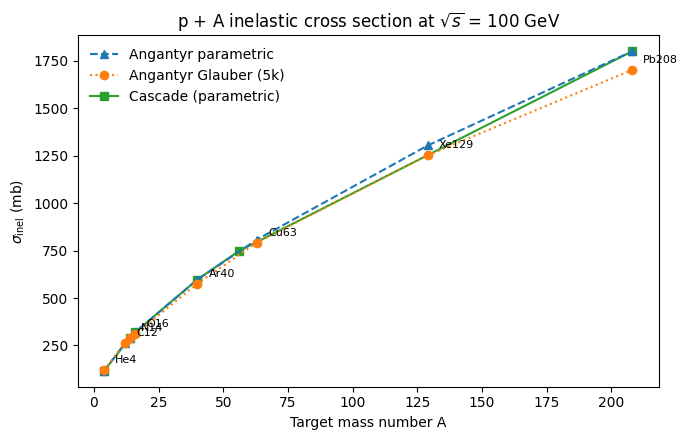

In [8]:
from chromo.util import name2pdg as _n2p

fig, ax = plt.subplots(figsize=(7, 4.5))

# Angantyr covers more targets
A_ang = [int(_n2p(t).A) for t in targets_angantyr]
ax.plot(A_ang, [sigma_angantyr_param[t] for t in targets_angantyr],
        "^--", label="Angantyr parametric", ms=6, zorder=2)
ax.plot(A_ang, [sigma_angantyr_glauber[t] for t in targets_angantyr],
        "o:", label="Angantyr Glauber (5k)", ms=6, zorder=3)

# Cascade covers fewer targets
A_cas = [int(_n2p(t).A) for t in targets_cascade]
ax.plot(A_cas, [sigma_cascade[t] for t in targets_cascade],
        "s-", label="Cascade (parametric)", ms=6, zorder=1)

for t in targets_angantyr:
    A = int(_n2p(t).A)
    ax.annotate(t, (A, sigma_angantyr_glauber[t]),
                textcoords="offset points", xytext=(8, 5), fontsize=8)

ax.set_xlabel("Target mass number A")
ax.set_ylabel(r"$\sigma_\mathrm{inel}$ (mb)")
ax.set_title(r"p + A inelastic cross section at $\sqrt{s}$ = 100 GeV")
ax.legend(frameon=False)
plt.tight_layout()

## 5. Multi-model comparison on p + O16

Compare nuclear production cross sections from all models that support
oxygen targets.

In [9]:
from chromo.util import name2pdg, get_all_models

energies_o16 = np.geomspace(30, 1e5, 12) * GeV

# Collect models that support O16 as a target
Models = []
for M in get_all_models():
    if name2pdg("O16") in M.targets and 2212 in M.projectiles:
        Models.append(M)

print("Models with O16 target:", [M.pyname for M in Models])

Models with O16 target: ['DpmjetIII191', 'DpmjetIII193', 'DpmjetIII307', 'EposLHC', 'EposLHCR', 'EposLHCRHadrRescattering', 'Pythia8Angantyr', 'Pythia8Cascade', 'QGSJet01d', 'QGSJetII03', 'QGSJetII04', 'QGSJetIII', 'Sibyll21', 'Sibyll23c', 'Sibyll23d', 'Sibyll23dStarMixed', 'Sibyll23e', 'Sibyll23eStarMixed', 'UrQMD34']


In [12]:
import joblib


@joblib.delayed
def run_o16(Model, projectile):
    """Compute production cross section vs energy for p + O16."""
    values = []
    ecm_max = energies_o16[-1]
    if hasattr(Model, "_ecm_min") and ecm_max < Model._ecm_min:
        return None

    try:
        m = Model(CenterOfMass(ecm_max, projectile, "O16"), seed=1, banner=False)
    except TypeError:
        try:
            m = Model(CenterOfMass(ecm_max, projectile, "O16"), seed=1)
        except Exception as e:
            print(f"  {Model.pyname}: init failed: {e}")
            return None
    except Exception as e:
        print(f"  {Model.pyname}: init failed: {e}")
        return None

    for ecm in energies_o16:
        if hasattr(Model, "_ecm_min") and ecm < Model._ecm_min:
            values.append(np.nan)
            continue
        try:
            kin = CenterOfMass(ecm, projectile, "O16")
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                cs = m.cross_section(kin)
            values.append(cs.prod)
        except Exception:
            values.append(np.nan)
    return np.array(values)


results = joblib.Parallel(n_jobs=len(Models), batch_size=1)(
    run_o16(M, "p") for M in Models
)

cross_sections_o16 = {}
for M, r in zip(Models, results):
    if r is not None:
        cross_sections_o16[M.pyname] = r

 +-----------------------------------------------------------------------+
 |                                                                       |
 |                       DPMJET-III version 19.1.7                       |
 |                                                                       |
 |                      (Last change:  10 Jun 2025)                      |
 |                                                                       |
 |            Authors:                                                   |
 |                     Stefan Roesler     (CERN)                         |
 |                     Anatoli Fedynitch (ASIoP)                         |
 |                     Ralph Engel        (KIT)                          |
 |                     Johannes Ranft     (Siegen Univ.)                 |
 |                                                                       |
 |        https://github.com/dpmjet/dpmjet                           |
 |                           

 +-----------------------------------------------------------------------+
 |                                                                       |
 |                       DPMJET-III version 19.3.8                       |
 |                                                                       |
 |                      (Last change:  10 Jun 2025)                      |
 |                                                                       |
 |            Authors:                                                   |
 |                     Stefan Roesler     (CERN)                         |
 |                     Anatoli Fedynitch (ASIoP)                         |
 |                     Ralph Engel        (KIT)                          |
 |                     Johannes Ranft     (Siegen Univ.)                 |
 |                                                                       |
 |        https://github.com/DPMJET/DPMJET                           |
 |                           

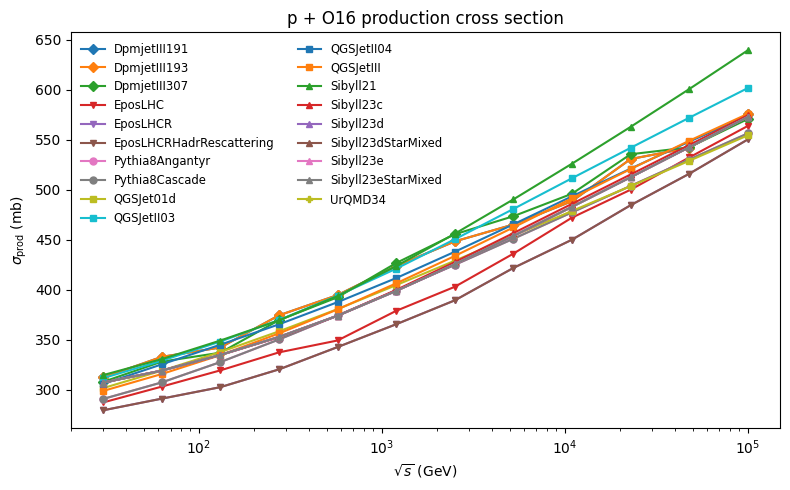

In [13]:
# Assign markers by model family
def _marker_for(name):
    if "Sibyll" in name:
        return "^"
    if "Pythia" in name:
        return "o"
    if "QGSJet" in name:
        return "s"
    if "Dpmjet" in name:
        return "D"
    if "Epos" in name:
        return "v"
    if "UrQMD" in name:
        return "P"
    return "x"


fig, ax = plt.subplots(figsize=(8, 5))

for name, sigma in sorted(cross_sections_o16.items()):
    ax.plot(energies_o16 / GeV, sigma, marker=_marker_for(name),
            ls="-", label=name, ms=5)

ax.set_xscale("log")
ax.set_xlabel(r"$\sqrt{s}$ (GeV)")
ax.set_ylabel(r"$\sigma_\mathrm{prod}$ (mb)")
ax.set_title("p + O16 production cross section")
ax.legend(frameon=False, fontsize="small", ncol=2)
plt.tight_layout()

In [14]:
results_pi = joblib.Parallel(n_jobs=len(Models), batch_size=1)(
    run_o16(M, "pi+") for M in Models
)

cross_sections_piplus_o16 = {}
for M, r in zip(Models, results_pi):
    if r is not None:
        cross_sections_piplus_o16[M.pyname] = r

 +-----------------------------------------------------------------------+
 |                                                                       |
 |                       DPMJET-III version 19.3.8                       |
 |                                                                       |
 |                      (Last change:  10 Jun 2025)                      |
 |                                                                       |
 |            Authors:                                                   |
 |                     Stefan Roesler     (CERN)                         |
 |                     Anatoli Fedynitch (ASIoP)                         |
 |                     Ralph Engel        (KIT)                          |
 |                     Johannes Ranft     (Siegen Univ.)                 |
 |                                                                       |
 |        https://github.com/DPMJET/DPMJET                           |
 |                           

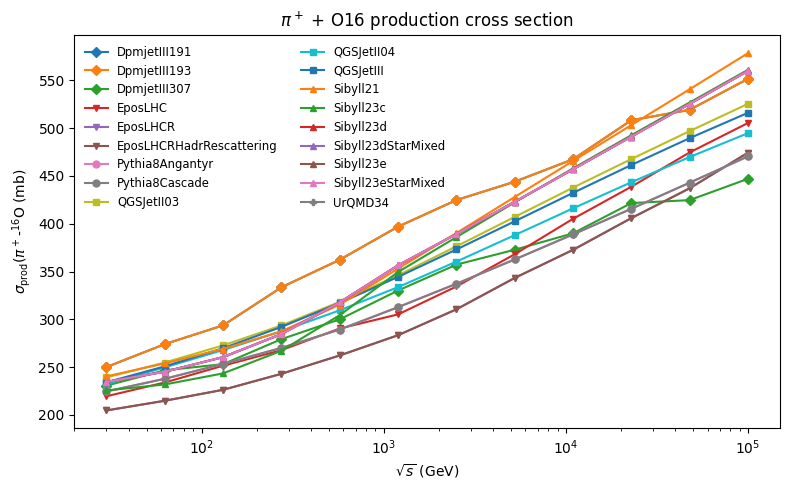

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, sigma in sorted(cross_sections_piplus_o16.items()):
    ax.plot(energies_o16 / GeV, sigma, marker=_marker_for(name),
            ls="-", label=name, ms=5)

ax.set_xscale("log")
ax.set_xlabel(r"$\sqrt{s}$ (GeV)")
ax.set_ylabel(r"$\sigma_\mathrm{prod}(\pi^+$-$^{16}$O (mb)")
ax.set_title(r"$\pi^+$ + O16 production cross section")
ax.legend(frameon=False, fontsize="small", ncol=2)
plt.tight_layout()